In [2]:
import sys
print(sys.executable)
print(sys.version)



C:\Anaconda3\python.exe
3.11.7 | packaged by Anaconda, Inc. | (main, Dec 15 2023, 18:05:47) [MSC v.1916 64 bit (AMD64)]


In [3]:
import sys
!"{sys.executable}" -m pip install torchsde


In [4]:
import torch
import torchsde

print("torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("torchsde imported OK")


torch: 2.9.0+cpu
CUDA available: False
torchsde imported OK


In [5]:
import datetime as dt
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import math
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler

import argparse
import logging
import os
import time
import random
from collections import namedtuple
from typing import Optional, Union
import torch
import torch.nn.functional as F
import torch.nn.init as init
from torch import nn, optim, distributions
import torch.backends.cudnn as cudnn
import tqdm
from scipy.stats import levy_stable
import torchsde
import seaborn as sns

def setup_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True

setup_seed(4)


In [6]:
# === Config for your exchange-rate dataset ===
DATA_PATH = r"Exchange rate data.xlsx"   # <-- make sure this matches your file path
TARGET_COLUMN = "Nigeria"
ASSET_NAME = f"{TARGET_COLUMN} exchange rate"

# === Load data ===
data = pd.read_excel(DATA_PATH)

# Make sure the date column is called 'Date'
date_col = "Date"

# Keep only the date + target series and rename
data = data[[date_col, TARGET_COLUMN]].copy()
data.columns = ["date", "close"]

# Convert to numeric (handle Excel strings)
data["close"] = pd.to_numeric(data["close"], errors="coerce")

# Drop invalid rows
data = data.dropna(subset=["close"]).reset_index(drop=True)

# Convert and clean dates
data["date"] = pd.to_datetime(data["date"], errors="coerce")
data = data.dropna(subset=["date"])

# === 🔴 CRITICAL FIX: ensure one observation per day ===
# Sort first
data = data.sort_values("date")

# Remove duplicates (keep last available value per day)
data = data.drop_duplicates(subset="date", keep="last").reset_index(drop=True)

# === Create OHLC-style structure for compatibility ===
data["open"] = data["close"]
data["high"] = data["close"]
data["low"]  = data["close"]
data["volume"] = 0.0

print("✅ Data loaded successfully!")
print(data.info())
data.head()



✅ Data loaded successfully!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3731 entries, 0 to 3730
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    3731 non-null   datetime64[ns]
 1   close   3731 non-null   float64       
 2   open    3731 non-null   float64       
 3   high    3731 non-null   float64       
 4   low     3731 non-null   float64       
 5   volume  3731 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 175.0 KB
None


,date,close,open,high,low,volume
0,2011-01-03,152.0,152.0,152.0,152.0,0.0
1,2011-01-04,152.3,152.3,152.3,152.3,0.0
2,2011-01-05,152.0,152.0,152.0,152.0,0.0
3,2011-01-06,152.0,152.0,152.0,152.0,0.0
4,2011-01-07,152.2,152.2,152.2,152.2,0.0


In [7]:
# === Data Cleaning and Splitting ===

# Create new dataframe with only relevant columns
stk_data = pd.DataFrame(columns=["Date", "Open", "High", "Low", "Close"])
stk_data["Date"] = data["date"]
stk_data["Open"] = data["open"]
stk_data["High"] = data["high"]
stk_data["Low"]  = data["low"]
stk_data["Close"] = data["close"]

stk_data.head()


,Date,Open,High,Low,Close
0,2011-01-03,152.0,152.0,152.0,152.0
1,2011-01-04,152.3,152.3,152.3,152.3
2,2011-01-05,152.0,152.0,152.0,152.0
3,2011-01-06,152.0,152.0,152.0,152.0
4,2011-01-07,152.2,152.2,152.2,152.2


In [8]:
# === Convert prices to log returns, then split ===

percent_training = 0.80

prices = stk_data["Close"].astype(float).values.reshape(-1, 1)

# log returns: r_t = log(P_t) - log(P_{t-1})
log_returns = np.diff(np.log(prices.flatten())).reshape(-1, 1)

# Dates align with returns from t=1 onward
return_dates = stk_data["Date"].iloc[1:].reset_index(drop=True)

num_training_samples = int(np.ceil(percent_training * len(log_returns)))

training_set = log_returns[:num_training_samples]
testing_set  = log_returns[num_training_samples:]

training_dates = return_dates.iloc[:num_training_samples].reset_index(drop=True)
testing_dates  = return_dates.iloc[num_training_samples:].reset_index(drop=True)

print("Training log-return shape:", training_set.shape)
print("Testing log-return shape:", testing_set.shape)


Training log-return shape: (2984, 1)
Testing log-return shape: (746, 1)


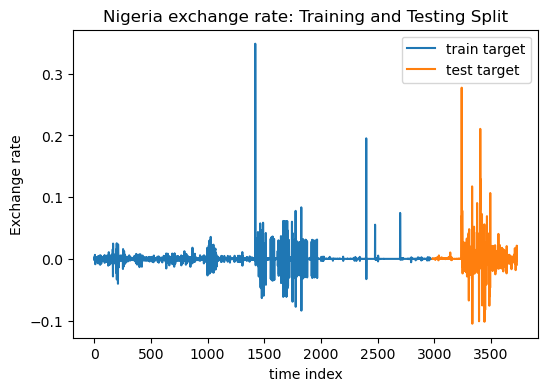

In [9]:
# Show train/test split on the series
plt.figure(figsize=(6, 4))
plt.plot(np.arange(training_set.shape[0]), training_set, label="train target")
plt.plot(
    np.arange(training_set.shape[0], training_set.shape[0] + testing_set.shape[0]),
    testing_set,
    label="test target"
)
plt.title(f"{ASSET_NAME}: Training and Testing Split")
plt.xlabel("time index")
plt.ylabel("Exchange rate")
plt.legend(loc="best")
plt.show()


In [10]:
# === Min-Max scale log returns to [-1, 1] ===
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1, 1))

# Fit ONLY on training data
training_set_scaled = scaler.fit_transform(training_set)

# Apply same scaler to test data (no leakage)
testing_set_scaled = scaler.transform(testing_set)

# Create aligned DataFrame (cleaner version)
training_set_scaled3 = pd.DataFrame({
    "Date": training_dates.values,
    "closescale": training_set_scaled.flatten()
})

training_set_scaled3.head()

,Date,closescale
0,2011-01-04,-0.603152
1,2011-01-05,-0.621389
2,2011-01-06,-0.612270
3,2011-01-07,-0.606189
4,2011-01-10,-0.600132


In [11]:
testing_set_scaled3 = pd.DataFrame({
    "Date": testing_dates.values,
    "closescale": testing_set_scaled.flatten()
})

testing_set_scaled3.head()

,Date,closescale
0,2022-06-17,-0.611378
1,2022-06-20,-0.612270
2,2022-06-21,-0.613608
3,2022-06-22,-0.613497
4,2022-06-23,-0.612828


In [12]:
# Phase-space reconstruction:
# df: DataFrame with columns [Date, value]
# tau: delay
# d: embedding dimension
# T: prediction horizon (steps ahead)
def PhaSpaRecon(df, tau, d, T):
    data = np.array(df)[:, 1]   # scaled values
    date = np.array(df)[:, 0]   # dates
    lens = len(data)
    if (lens - T - (d - 1) * tau) < 1:
        print("error: delay time or the embedding dimension is too large")
    else:
        Xn1 = np.zeros((d, lens - (d - 1) * tau - 1))
        for i in range(d):
            Xn1[i, :] = data[i * tau : i * tau + lens - (d - 1) * tau - 1]

        Yn1 = data[(T + (d - 1) * tau) : T + (d - 1) * tau + lens - (d - 1) * tau - 1]
        Yn1_date = date[(T + (d - 1) * tau) : T + (d - 1) * tau + lens - (d - 1) * tau - 1]

        Yn = Yn1.reshape((len(Yn1), 1))
        Yn_date = Yn1_date.reshape((len(Yn1_date), 1))
        Yn = pd.DataFrame(Yn)
        Yn_date = pd.DataFrame(Yn_date)
        Y = pd.concat([Yn_date, Yn], axis=1)

        Xn = Xn1.T
        Xn = pd.DataFrame(Xn)
        X = pd.concat([Xn, Yn], axis=1)
    return Xn, Yn, Y, X


In [13]:
tau = 1
d = 12       # or your estimated embedding dimension (e.g. 30)
T = 1        # 1-step ahead

# Train reconstruction
Xn, Yn, Y, X = PhaSpaRecon(training_set_scaled3, tau=tau, d=d, T=T)
train = X.values
x_train1 = train[:, 0:d]
y_train1 = train[:, d]

# Test reconstruction
X1n, Y1n, Y1, X1 = PhaSpaRecon(testing_set_scaled3, tau=tau, d=d, T=T)
test = X1.values
x_test1 = test[:, 0:d]
y_test1 = test[:, d]

print(
    "x_train1 shape:", x_train1.shape,
    "\nx_test1 shape:", x_test1.shape,
    "\ny_train1 shape:", y_train1.shape,
    "\ny_test1 shape:", y_test1.shape
)


x_train1 shape: (2972, 12) 
x_test1 shape: (734, 12) 
y_train1 shape: (2972,) 
y_test1 shape: (734,)


In [14]:
# Simple time index for plotting later (optional)
ts_      = np.arange(0, y_train1.shape[0])
ts_ext_  = np.arange(y_train1.shape[0], y_train1.shape[0] + y_test1.shape[0])
ts_full_ = np.arange(0, y_train1.shape[0] + y_test1.shape[0])


x_train shape: (2972, 12)
y_train shape: (2972,)
x_test shape: (734, 12)
y_test shape: (734,)
Using device: cpu
SDENet1(
  (downsampling_layers): Linear(in_features=12, out_features=12, bias=True)
  (drift): Drift1(
    (net): Sequential(
      (0): Linear(in_features=12, out_features=12, bias=True)
      (1): Tanh()
    )
  )
  (diffusion): Diffusion1(
    (net): Sequential(
      (0): Linear(in_features=12, out_features=12, bias=True)
      (1): Softplus(beta=1.0, threshold=20.0)
    )
  )
  (readout): Linear(in_features=12, out_features=1, bias=True)
)
Epoch   1/100  Train MSE: 1.039713  Test MSE: 0.791693
Epoch  10/100  Train MSE: 0.031850  Test MSE: 0.106005
Epoch  20/100  Train MSE: 0.028417  Test MSE: 0.096024
Epoch  30/100  Train MSE: 0.024925  Test MSE: 0.084927
Epoch  40/100  Train MSE: 0.021650  Test MSE: 0.074877
Epoch  50/100  Train MSE: 0.018643  Test MSE: 0.065325
Epoch  60/100  Train MSE: 0.015825  Test MSE: 0.056603
Epoch  70/100  Train MSE: 0.013303  Test MSE: 0.04876

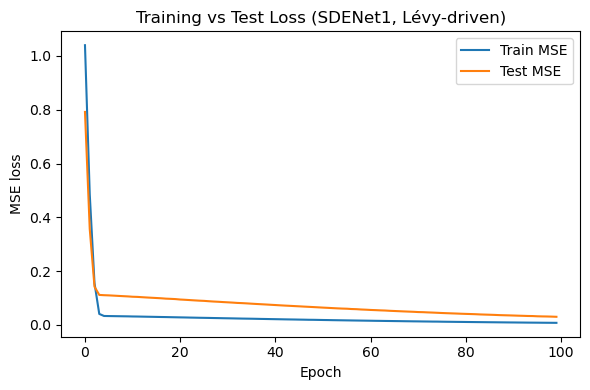

y_train mean/std: -0.61071074 0.0547317
y_test mean/std : -0.60395825 0.10065707
pred mean/std   : -0.60389555 0.05128957

SDE-Net single run
Test MSE  : 0.012057
Test RMSE : 0.109803
Test MAE  : 0.050192
Test SMAPE: 8.969%

Zero-return baseline
Zero MSE  : 0.374897
Zero RMSE : 0.612289
Zero MAE  : 0.606772
Zero SMAPE: 200.000%

SDE-Net improvement over zero baseline
MSE improvement: 0.362841
MAE improvement: 0.556580


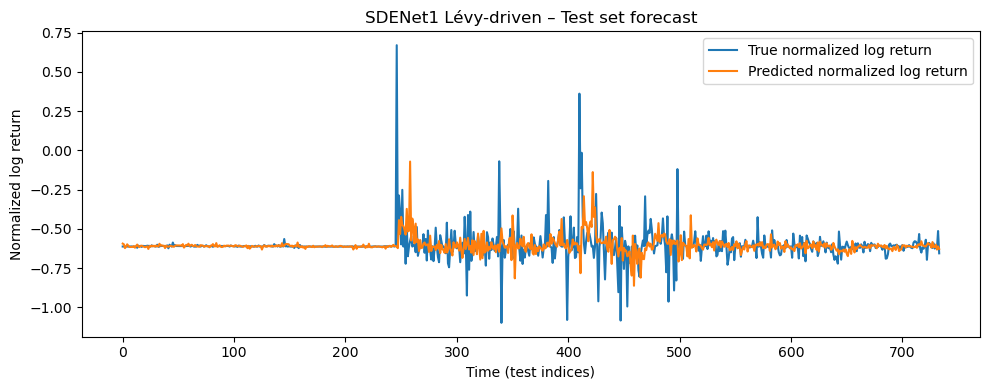

Seed 0: MSE=0.011936, RMSE=0.109251, MAE=0.048601, SMAPE=8.571%
Seed 1: MSE=0.012740, RMSE=0.112872, MAE=0.052541, SMAPE=9.362%
Seed 2: MSE=0.012331, RMSE=0.111043, MAE=0.050948, SMAPE=9.116%
Seed 3: MSE=0.011414, RMSE=0.106836, MAE=0.047539, SMAPE=8.343%
Seed 4: MSE=0.010925, RMSE=0.104523, MAE=0.045936, SMAPE=8.052%

=== SDE-Net Error Bars over 5 seeds ===
MSE: 0.011869 ± 0.000720
RMSE: 0.108905 ± 0.003313
MAE: 0.049113 ± 0.002643
SMAPE: 8.688850 ± 0.541764


,Seed,MSE,RMSE,MAE,SMAPE
0,0,0.011936,0.109251,0.048601,8.571250
1,1,0.012740,0.112872,0.052541,9.361619
2,2,0.012331,0.111043,0.050948,9.116182
3,3,0.011414,0.106836,0.047539,8.343067
4,4,0.010925,0.104523,0.045936,8.052135


In [15]:
# ==============================
# 1. Bind reconstructed data
# ==============================
x_train = x_train1
y_train = y_train1
x_test  = x_test1
y_test  = y_test1

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

# ==============================
# 2. Ensure numeric
# ==============================
def ensure_numeric(a):
    if isinstance(a, pd.DataFrame):
        a = a.values
    a = np.asarray(a, dtype=np.float32)
    if np.isnan(a).any():
        print("⚠️ Still found NaNs – replacing with 0.")
        a = np.nan_to_num(a)
    return a

x_train = ensure_numeric(x_train)
x_test  = ensure_numeric(x_test)
y_train = ensure_numeric(y_train)
y_test  = ensure_numeric(y_test)

# ==============================
# 3. Imports, tensors & loaders
# ==============================
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import math
import matplotlib.pyplot as plt

from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import levy_stable

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

x_train_t = torch.tensor(x_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)

x_test_t = torch.tensor(x_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(device)

batch_size = 64

train_dataset = TensorDataset(x_train_t, y_train_t)
test_dataset  = TensorDataset(x_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# ==============================
# 4. SDENet1 – stable refined version
# ==============================
sequence_length = x_train.shape[1]
alpha, beta = 1.2, 0.0

class Drift1(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.Tanh()
        )

    def forward(self, t, x):
        return self.net(x)


class Diffusion1(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.Softplus()
        )

    def forward(self, t, x):
        return self.net(x)


class SDENet1(nn.Module):
    """
    Stable version:
    X_{k+1} = X_k + f(X_k) * dt
              + sigma * g(X_0) * dt^(1/alpha) * ΔL_k

    Diffusion is fixed per forward pass for numerical stability.
    """
    def __init__(self, dim, layer_depth=6, alpha=1.2, beta=0.0, sigma=0.12, levy_scale=0.015):
        super().__init__()

        self.dim = dim
        self.layer_depth = layer_depth
        self.alpha = alpha
        self.beta = beta
        self.sigma = sigma
        self.levy_scale = levy_scale

        self.downsampling_layers = nn.Linear(dim, dim)
        self.drift = Drift1(dim)
        self.diffusion = Diffusion1(dim)

        self.deltat = 1.0 / layer_depth
        self.readout = nn.Linear(dim, 1)

    def _levy_noise(self, batch_size):
        noise_np = levy_stable.rvs(
            self.alpha,
            self.beta,
            size=(batch_size, self.dim),
            scale=self.levy_scale
        ).astype(np.float32)

        return torch.from_numpy(noise_np)

    def forward(self, x, training_diffusion=False):
        batch_size = x.shape[0]
        out = self.downsampling_layers(x)

        initial_state = out.clone()

        # Fixed diffusion per forward pass for numerical stability
        t0 = 0.0
        diffusion_term = self.sigma * self.diffusion(t0, out)
            
        for i in range(self.layer_depth):
            t = float(i) / self.layer_depth

            drift = self.drift(t, out)

            noise = self._levy_noise(batch_size).to(out.device)
            noise = torch.clamp(noise, -5.0, 5.0)   # ← ADD THIS LINE

            out = out + drift * self.deltat \
                  + diffusion_term * (self.deltat ** (1.0 / self.alpha)) * noise

        return self.readout(out), self.readout(initial_state)

# ==============================
# 5. Metric helpers
# ==============================
def smape(y_true, y_pred, eps=1e-8):
    return 100 * np.mean(
        2 * np.abs(y_pred - y_true) /
        (np.abs(y_true) + np.abs(y_pred) + eps)
    )

def compute_all_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1, 1)
    y_pred = np.asarray(y_pred).reshape(-1, 1)

    mse = mean_squared_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    s_mape = smape(y_true, y_pred)

    return mse, rmse, mae, s_mape

# ==============================
# 6. Single-run training
# ==============================
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

model = SDENet1(
    dim=sequence_length,
    layer_depth=6,
    alpha=alpha,
    beta=beta,
    sigma=0.12,
    levy_scale=0.025
).to(device)

print(model)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

omega_D = 1.0
omega_B = 10.0

num_epochs = 100
train_losses = []
test_losses = []

for epoch in range(1, num_epochs + 1):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds, init_pred = model(xb)

        L_data = criterion(preds, yb)

        x0 = xb[:, 0].unsqueeze(1)
        L_B = criterion(init_pred, x0)

        loss = omega_D * L_data + omega_B * L_B

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running_loss += loss.item() * xb.size(0)

    epoch_train_loss = running_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)

    model.eval()
    test_running_loss = 0.0

    with torch.no_grad():
        for xb, yb in test_loader:
            preds, init_pred = model(xb)

            L_data = criterion(preds, yb)

            x0 = xb[:, 0].unsqueeze(1)
            L_B = criterion(init_pred, x0)

            loss = omega_D * L_data + omega_B * L_B

            test_running_loss += loss.item() * xb.size(0)

    epoch_test_loss = test_running_loss / len(test_dataset)
    test_losses.append(epoch_test_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:3d}/{num_epochs}  "
            f"Train MSE: {epoch_train_loss:.6f}  "
            f"Test MSE: {epoch_test_loss:.6f}"
        )

# ==============================
# 7. Loss curves
# ==============================
plt.figure(figsize=(6, 4))
plt.plot(train_losses, label="Train MSE")
plt.plot(test_losses, label="Test MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training vs Test Loss (SDENet1, Lévy-driven)")
plt.legend()
plt.tight_layout()
plt.show()

# ==============================
# 8. Single-run predictions
# ==============================
model.eval()
with torch.no_grad():
    y_train_pred_eval, _ = model(x_train_t)
    y_test_pred_eval, _  = model(x_test_t)

    y_train_pred_eval = y_train_pred_eval.cpu().numpy().reshape(-1, 1)
    y_test_pred_eval  = y_test_pred_eval.cpu().numpy().reshape(-1, 1)

y_train_eval = y_train.reshape(-1, 1)
y_test_eval  = y_test.reshape(-1, 1)

# ==============================
# 9. Single-run metrics + zero baseline
# ==============================
mse_test, rmse_test, mae_test, smape_test = compute_all_metrics(y_test_eval, y_test_pred_eval)

print("y_train mean/std:", y_train.mean(), y_train.std())
print("y_test mean/std :", y_test.mean(), y_test.std())
print("pred mean/std   :", y_test_pred_eval.mean(), y_test_pred_eval.std())

print("\nSDE-Net single run")
print(f"Test MSE  : {mse_test:.6f}")
print(f"Test RMSE : {rmse_test:.6f}")
print(f"Test MAE  : {mae_test:.6f}")
print(f"Test SMAPE: {smape_test:.3f}%")

zero_pred = np.zeros_like(y_test_eval)
zero_mse, zero_rmse, zero_mae, zero_smape = compute_all_metrics(y_test_eval, zero_pred)

print("\nZero-return baseline")
print(f"Zero MSE  : {zero_mse:.6f}")
print(f"Zero RMSE : {zero_rmse:.6f}")
print(f"Zero MAE  : {zero_mae:.6f}")
print(f"Zero SMAPE: {zero_smape:.3f}%")

print("\nSDE-Net improvement over zero baseline")
print(f"MSE improvement: {zero_mse - mse_test:.6f}")
print(f"MAE improvement: {zero_mae - mae_test:.6f}")

# ==============================
# 10. Plot true vs predicted normalized log returns
# ==============================
plt.figure(figsize=(10, 4))
plt.plot(y_test_eval, label="True normalized log return")
plt.plot(y_test_pred_eval, label="Predicted normalized log return")
plt.xlabel("Time (test indices)")
plt.ylabel("Normalized log return")
plt.title("SDENet1 Lévy-driven – Test set forecast")
plt.legend()
plt.tight_layout()
plt.show()

# ==============================
# 11. Multi-seed error bars for SDE-Net
# ==============================
def run_sdenet_once(seed, num_epochs=100):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model_seed = SDENet1(
        dim=sequence_length,
        layer_depth=6,
        alpha=alpha,
        beta=beta,
        sigma=0.12,
        levy_scale=0.025
    ).to(device)

    optimizer_seed = optim.Adam(model_seed.parameters(), lr=1e-4)
    criterion_seed = nn.MSELoss()

    for epoch in range(num_epochs):
        model_seed.train()

        for xb, yb in train_loader:
            optimizer_seed.zero_grad()
            preds, init_pred = model_seed(xb)

            L_data = criterion_seed(preds, yb)

            x0 = xb[:, 0].unsqueeze(1)
            L_B = criterion_seed(init_pred, x0)

            loss = omega_D * L_data + omega_B * L_B

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_seed.parameters(), max_norm=1.0)
            optimizer_seed.step()

    model_seed.eval()
    with torch.no_grad():
        preds, _ = model_seed(x_test_t)
        preds = preds.cpu().numpy().reshape(-1, 1)

    mse, rmse, mae, s_mape = compute_all_metrics(y_test_eval, preds)

    return mse, rmse, mae, s_mape


seeds = [0, 1, 2, 3, 4]

sdenet_seed_results = []

for s in seeds:
    mse, rmse, mae, s_mape = run_sdenet_once(s, num_epochs=100)

    print(
        f"Seed {s}: "
        f"MSE={mse:.6f}, RMSE={rmse:.6f}, "
        f"MAE={mae:.6f}, SMAPE={s_mape:.3f}%"
    )

    sdenet_seed_results.append({
        "Seed": s,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "SMAPE": s_mape
    })

sdenet_seed_df = pd.DataFrame(sdenet_seed_results)

print("\n=== SDE-Net Error Bars over 5 seeds ===")
for metric in ["MSE", "RMSE", "MAE", "SMAPE"]:
    mean_val = sdenet_seed_df[metric].mean()
    std_val = sdenet_seed_df[metric].std(ddof=1)
    print(f"{metric}: {mean_val:.6f} ± {std_val:.6f}")

display(sdenet_seed_df)

In [16]:
# ============================================================
# Gambia TABLE — normalized log-return evaluation with error bars
# ============================================================

import numpy as np
import pandas as pd
import math
import random

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.neural_network import MLPRegressor

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# ------------------------------
# Bind arrays
# ------------------------------
x_train = ensure_numeric(x_train1)
x_test  = ensure_numeric(x_test1)
y_train = ensure_numeric(y_train1).reshape(-1, 1)
y_test  = ensure_numeric(y_test1).reshape(-1, 1)

y_train_eval = y_train
y_test_eval  = y_test

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------
# Metrics
# ------------------------------
def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true).reshape(-1, 1)
    y_pred = np.asarray(y_pred).reshape(-1, 1)

    return 100 * np.mean(
        2 * np.abs(y_pred - y_true) /
        (np.abs(y_true) + np.abs(y_pred) + eps)
    )

def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1, 1)
    y_pred = np.asarray(y_pred).reshape(-1, 1)

    mse = mean_squared_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    s_mape = smape(y_true, y_pred)

    return mse, rmse, mae, s_mape

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def summarise_metric_rows(rows, model_name):
    df_tmp = pd.DataFrame(rows)

    return {
        "Data": "Gambia",
        "Model": model_name,
        "MSE": f"{df_tmp['MSE'].mean():.6f} ± {df_tmp['MSE'].std(ddof=1):.6f}",
        "RMSE": f"{df_tmp['RMSE'].mean():.6f} ± {df_tmp['RMSE'].std(ddof=1):.6f}",
        "MAE": f"{df_tmp['MAE'].mean():.6f} ± {df_tmp['MAE'].std(ddof=1):.6f}",
        "SMAPE": f"{df_tmp['SMAPE'].mean():.3f} ± {df_tmp['SMAPE'].std(ddof=1):.3f}",
    }

def get_metric_row(model_name, y_pred):
    mse, rmse, mae, s_mape = compute_metrics(y_test_eval, y_pred)
    return {
        "Data": "Gambia",
        "Model": model_name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "SMAPE": s_mape
    }

seeds = [0, 1, 2, 3, 4]
summary_rows = []
raw_rows = []

# ============================================================
# 0) Zero-return baseline
# ============================================================
zero_pred = np.zeros_like(y_test_eval)
zero_row = get_metric_row("Zero baseline", zero_pred)
summary_rows.append({
    "Data": "Gambia",
    "Model": "Zero baseline",
    "MSE": f"{zero_row['MSE']:.6f}",
    "RMSE": f"{zero_row['RMSE']:.6f}",
    "MAE": f"{zero_row['MAE']:.6f}",
    "SMAPE": f"{zero_row['SMAPE']:.3f}",
})

# ============================================================
# 1) ANN baseline with error bars
# ============================================================
ann_rows = []

for seed in seeds:
    set_seed(seed)

    ann = MLPRegressor(
        hidden_layer_sizes=(64, 64),
        activation="relu",
        solver="adam",
        max_iter=500,
        random_state=seed
    )

    ann.fit(x_train, y_train_eval.flatten())
    ann_pred = ann.predict(x_test).reshape(-1, 1)

    row = get_metric_row("ANN", ann_pred)
    row["Seed"] = seed
    ann_rows.append(row)
    raw_rows.append(row)

summary_rows.append(summarise_metric_rows(ann_rows, "ANN"))

# ============================================================
# 2) LSTM baseline with error bars
# ============================================================
class LSTMRegressor(nn.Module):
    def __init__(self, hidden=64, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        return self.fc(last)

def run_lstm_once(seed, epochs=30):
    set_seed(seed)

    Xtr = torch.tensor(x_train, dtype=torch.float32).unsqueeze(-1).to(device)
    ytr = torch.tensor(y_train_eval, dtype=torch.float32).to(device)
    Xte = torch.tensor(x_test, dtype=torch.float32).unsqueeze(-1).to(device)

    train_loader_lstm = DataLoader(
        TensorDataset(Xtr, ytr),
        batch_size=64,
        shuffle=True
    )

    model = LSTMRegressor(hidden=64, num_layers=1).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    for ep in range(epochs):
        model.train()

        for xb, yb in train_loader_lstm:
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        pred = model(Xte).cpu().numpy().reshape(-1, 1)

    return pred

lstm_rows = []

for seed in seeds:
    lstm_pred = run_lstm_once(seed, epochs=30)

    row = get_metric_row("LSTM", lstm_pred)
    row["Seed"] = seed
    lstm_rows.append(row)
    raw_rows.append(row)

summary_rows.append(summarise_metric_rows(lstm_rows, "LSTM"))

# ============================================================
# 3) AR(1) baseline on normalized log returns
# ============================================================
try:
    from statsmodels.tsa.ar_model import AutoReg

    ytr_ar = y_train_eval.flatten()
    yte_ar = y_test_eval.flatten()

    ar_model = AutoReg(ytr_ar, lags=1, old_names=False).fit()
    ar_pred = ar_model.predict(
        start=len(ytr_ar),
        end=len(ytr_ar) + len(yte_ar) - 1
    ).reshape(-1, 1)

    ar_row = get_metric_row("AR(1)", ar_pred)

    summary_rows.append({
        "Data": "Gambia",
        "Model": "AR(1)",
        "MSE": f"{ar_row['MSE']:.6f}",
        "RMSE": f"{ar_row['RMSE']:.6f}",
        "MAE": f"{ar_row['MAE']:.6f}",
        "SMAPE": f"{ar_row['SMAPE']:.3f}",
    })

except Exception as e:
    print("[AR(1)] Error:", e)
# ============================================================
# 4) GARCH baseline on normalized log returns
# ============================================================
try:
    from arch import arch_model

    ytr_garch = y_train_eval.flatten()

    am = arch_model(
        ytr_garch,
        mean="Constant",
        vol="GARCH",
        p=1,
        q=1,
        rescale=False
    )

    res = am.fit(disp="off")
    fc = res.forecast(horizon=len(y_test_eval))

    garch_pred = fc.mean.values[-1, :].reshape(-1, 1)

    garch_row = get_metric_row("GARCH(1,1)", garch_pred)

    summary_rows.append({
        "Data": "Nigeria",
        "Model": "GARCH(1,1)",
        "MSE": f"{garch_row['MSE']:.6f}",
        "RMSE": f"{garch_row['RMSE']:.6f}",
        "MAE": f"{garch_row['MAE']:.6f}",
        "SMAPE": f"{garch_row['SMAPE']:.3f}",
    })

except Exception as e:
    print("[GARCH] Error:", e)

# ============================================================
# 5) SDE-Net Lévy and Gaussian baselines with error bars
# ============================================================
def run_sdenet_once(seed, alpha_value=1.2, model_name="SDE-Net Lévy", epochs=100):
    set_seed(seed)

    Xtr = torch.tensor(x_train, dtype=torch.float32).to(device)
    ytr = torch.tensor(y_train_eval, dtype=torch.float32).to(device)
    Xte = torch.tensor(x_test, dtype=torch.float32).to(device)

    train_loader_sde = DataLoader(
        TensorDataset(Xtr, ytr),
        batch_size=64,
        shuffle=True
    )

    model = SDENet1(
        dim=x_train.shape[1],
        layer_depth=6,
        alpha=alpha_value,
        beta=0.0,
        sigma=0.12,
        levy_scale=0.025
    ).to(device)

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    for ep in range(epochs):
        model.train()

        for xb, yb in train_loader_sde:
            optimizer.zero_grad()

            pred, init_pred = model(xb)

            L_data = criterion(pred, yb)

            x0 = xb[:, 0].unsqueeze(1)
            L_B = criterion(init_pred, x0)

            loss = L_data + 10.0 * L_B

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

    model.eval()
    with torch.no_grad():
        pred, _ = model(Xte)
        pred = pred.cpu().numpy().reshape(-1, 1)

    return pred
# Lévy SDE-Net: alpha = 1.2
sde_levy_rows = []

for seed in seeds:
    pred = run_sdenet_once(seed, alpha_value=1.2, model_name="SDE-Net Lévy", epochs=100)

    row = get_metric_row("SDE-Net Lévy α=1.2", pred)
    row["Seed"] = seed
    sde_levy_rows.append(row)
    raw_rows.append(row)

summary_rows.append(summarise_metric_rows(sde_levy_rows, "SDE-Net Lévy α=1.2"))

# Gaussian/Brownian SDE-Net: alpha = 2.0
sde_gauss_rows = []

for seed in seeds:
    pred = run_sdenet_once(seed, alpha_value=2.0, model_name="SDE-Net Gaussian", epochs=100)

    row = get_metric_row("SDE-Net Gaussian α=2.0", pred)
    row["Seed"] = seed
    sde_gauss_rows.append(row)
    raw_rows.append(row)

summary_rows.append(summarise_metric_rows(sde_gauss_rows, "SDE-Net Gaussian α=2.0"))

# ============================================================
# 6) Display final table
# ============================================================
df_summary = pd.DataFrame(summary_rows)
df_raw = pd.DataFrame(raw_rows)

print("\n===== Gambia SUMMARY TABLE: mean ± std over 5 seeds where applicable =====")
display(df_summary)

print("\n===== RAW SEED RESULTS =====")
display(df_raw)

print("\nLaTeX export:\n")
print(df_summary.to_latex(index=False, escape=False))


===== Gambia SUMMARY TABLE: mean ± std over 5 seeds where applicable =====


,Data,Model,MSE,RMSE,MAE,SMAPE
0,Gambia,Zero baseline,0.374897,0.612289,0.606772,200.000
1,Gambia,ANN,0.010729 ± 0.000109,0.103579 ± 0.000525,0.045856 ± 0.002035,7.977 ± 0.352
2,Gambia,LSTM,0.010147 ± 0.000102,0.100731 ± 0.000508,0.042653 ± 0.002422,7.473 ± 0.406
3,Gambia,AR(1),0.010177,0.100883,0.039938,7.020
4,Nigeria,"GARCH(1,1)",0.010161,0.100801,0.040153,7.057
5,Gambia,SDE-Net Lévy α=1.2,0.011869 ± 0.000720,0.108905 ± 0.003313,0.049113 ± 0.002643,8.689 ± 0.542
6,Gambia,SDE-Net Gaussian α=2.0,0.011881 ± 0.000709,0.108962 ± 0.003265,0.048586 ± 0.002605,8.604 ± 0.539



===== RAW SEED RESULTS =====


,Data,Model,MSE,RMSE,MAE,SMAPE,Seed
0,Gambia,ANN,0.010720,0.103538,0.049025,8.532660,0
1,Gambia,ANN,0.010813,0.103985,0.046459,8.060326,1
2,Gambia,ANN,0.010577,0.102846,0.044706,7.795113,2
3,Gambia,ANN,0.010851,0.104169,0.043709,7.604443,3
4,Gambia,ANN,0.010682,0.103354,0.045382,7.894556,4
5,Gambia,LSTM,0.010046,0.100231,0.040877,7.184144,0
6,Gambia,LSTM,0.010152,0.100755,0.046201,8.078106,1
7,Gambia,LSTM,0.010067,0.100334,0.042634,7.477086,2
8,Gambia,LSTM,0.010305,0.101514,0.043534,7.595710,3
9,Gambia,LSTM,0.010165,0.100824,0.040017,7.032415,4



LaTeX export:

\begin{tabular}{llllll}
\toprule
Data & Model & MSE & RMSE & MAE & SMAPE \\
\midrule
Gambia & Zero baseline & 0.374897 & 0.612289 & 0.606772 & 200.000 \\
Gambia & ANN & 0.010729 ± 0.000109 & 0.103579 ± 0.000525 & 0.045856 ± 0.002035 & 7.977 ± 0.352 \\
Gambia & LSTM & 0.010147 ± 0.000102 & 0.100731 ± 0.000508 & 0.042653 ± 0.002422 & 7.473 ± 0.406 \\
Gambia & AR(1) & 0.010177 & 0.100883 & 0.039938 & 7.020 \\
Nigeria & GARCH(1,1) & 0.010161 & 0.100801 & 0.040153 & 7.057 \\
Gambia & SDE-Net Lévy α=1.2 & 0.011869 ± 0.000720 & 0.108905 ± 0.003313 & 0.049113 ± 0.002643 & 8.689 ± 0.542 \\
Gambia & SDE-Net Gaussian α=2.0 & 0.011881 ± 0.000709 & 0.108962 ± 0.003265 & 0.048586 ± 0.002605 & 8.604 ± 0.539 \\
\bottomrule
\end{tabular}



In [17]:
# ======================================================
# Synthetic Lévy OU recovery experiment for alpha
# ======================================================

import numpy as np
import pandas as pd
from scipy.stats import levy_stable
from scipy.optimize import minimize_scalar

# ----------------------------
# 1. Simulate alpha-stable OU
# ----------------------------

def simulate_levy_ou(
    alpha=1.5,
    theta=0.08,
    sigma=0.05,
    x0=0.0,
    n=2500,
    dt=1.0,
    seed=0
):
    np.random.seed(seed)

    x = np.zeros(n)
    x[0] = x0

    # alpha-stable increments scale as dt^(1/alpha)
    dL = levy_stable.rvs(
        alpha=alpha,
        beta=0.0,
        loc=0.0,
        scale=dt ** (1 / alpha),
        size=n - 1
    )

    for t in range(n - 1):
        x[t + 1] = x[t] - theta * x[t] * dt + sigma * dL[t]

    return x


# ----------------------------
# 2. Estimate alpha from OU residuals
# ----------------------------

def estimate_alpha_from_ou_residuals(x):
    """
    Estimate alpha by:
    1. fitting OU drift approximately by OLS
    2. extracting residual innovations
    3. fitting alpha-stable alpha via likelihood
    """

    x_t = x[:-1]
    x_next = x[1:]

    # AR(1)-style OU discretisation:
    # x_{t+1} = phi x_t + error
    phi = np.sum(x_t * x_next) / np.sum(x_t ** 2)

    residuals = x_next - phi * x_t
    residuals = residuals - np.median(residuals)

    # robust scale initialization
    scale_init = np.median(np.abs(residuals)) / 0.6745
    scale_init = max(scale_init, 1e-6)

    def neg_loglik(alpha):
        if alpha <= 1.01 or alpha > 2.0:
            return np.inf

        try:
            ll = levy_stable.logpdf(
                residuals,
                alpha=alpha,
                beta=0.0,
                loc=0.0,
                scale=scale_init
            )
            if np.any(~np.isfinite(ll)):
                return np.inf
            return -np.sum(ll)

        except Exception:
            return np.inf

    res = minimize_scalar(
        neg_loglik,
        bounds=(1.05, 2.0),
        method="bounded",
        options={"xatol": 1e-3}
    )

    alpha_hat = res.x

    return alpha_hat, phi, scale_init


# ----------------------------
# 3. Run recovery experiment
# ----------------------------

def run_alpha_recovery_experiment(
    alpha_values=[1.2, 1.5, 1.8],
    seeds=[0, 1, 2, 3, 4],
    n=2500,
    theta=0.08,
    sigma=0.05,
    dt=1.0
):
    rows = []

    for alpha_true in alpha_values:
        estimates = []

        for seed in seeds:
            x = simulate_levy_ou(
                alpha=alpha_true,
                theta=theta,
                sigma=sigma,
                n=n,
                dt=dt,
                seed=seed
            )

            alpha_hat, phi_hat, scale_hat = estimate_alpha_from_ou_residuals(x)
            estimates.append(alpha_hat)

            rows.append({
                "alpha_true": alpha_true,
                "seed": seed,
                "alpha_hat": alpha_hat,
                "abs_error": abs(alpha_hat - alpha_true),
                "phi_hat": phi_hat,
                "scale_hat": scale_hat
            })

    raw_df = pd.DataFrame(rows)

    summary_df = (
        raw_df
        .groupby("alpha_true")
        .agg(
            alpha_hat_mean=("alpha_hat", "mean"),
            alpha_hat_std=("alpha_hat", "std"),
            abs_error_mean=("abs_error", "mean"),
            abs_error_std=("abs_error", "std")
        )
        .reset_index()
    )

    return raw_df, summary_df


# ----------------------------
# 4. Run and save
# ----------------------------

raw_df, summary_df = run_alpha_recovery_experiment(
    alpha_values=[1.2, 1.5, 1.8],
    seeds=[0, 1, 2, 3, 4],
    n=2500,
    theta=0.08,
    sigma=0.05,
    dt=1.0
)

print("\n===== RAW RESULTS =====")
print(raw_df)

print("\n===== SUMMARY RESULTS =====")
print(summary_df)

raw_df.to_csv("synthetic_alpha_recovery_raw.csv", index=False)
summary_df.to_csv("synthetic_alpha_recovery_summary.csv", index=False)

print("\nSaved:")
print("synthetic_alpha_recovery_raw.csv")
print("synthetic_alpha_recovery_summary.csv")


===== RAW RESULTS =====
    alpha_true  seed  alpha_hat  abs_error   phi_hat  scale_hat
0          1.2     0   1.217084   0.017084  0.920153   0.073075
1          1.2     1   1.273816   0.073816  0.918710   0.071497
2          1.2     2   1.298536   0.098536  0.935947   0.073967
3          1.2     3   1.282227   0.082227  0.924806   0.070622
4          1.2     4   1.306306   0.106306  0.910220   0.075120
5          1.5     0   1.584530   0.084530  0.918240   0.071766
6          1.5     1   1.635747   0.135747  0.915865   0.070123
7          1.5     2   1.632528   0.132528  0.933347   0.071918
8          1.5     3   1.632606   0.132606  0.928471   0.070994
9          1.5     4   1.674729   0.174729  0.917205   0.072761
10         1.8     0   1.869339   0.069339  0.914737   0.071627
11         1.8     1   1.933499   0.133499  0.915986   0.069563
12         1.8     2   1.903398   0.103398  0.927013   0.070215
13         1.8     3   1.935488   0.135488  0.923486   0.070346
14         1.8 

In [18]:
# ============================================================
# Gambia — LDE-Net alpha sensitivity sweep
# Runs ONLY LDE-Net for alpha = 1.2, 1.4, 1.6, 1.8, 2.0
# Assumes SDENet1, ensure_numeric, x_train1, x_test1, y_train1, y_test1
# are already defined.
# ============================================================

import numpy as np
import pandas as pd
import math
import random

from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# ------------------------------
# Bind arrays
# ------------------------------
x_train = ensure_numeric(x_train1)
x_test  = ensure_numeric(x_test1)
y_train = ensure_numeric(y_train1).reshape(-1, 1)
y_test  = ensure_numeric(y_test1).reshape(-1, 1)

y_train_eval = y_train
y_test_eval  = y_test

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------
# Metrics
# ------------------------------
def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true).reshape(-1, 1)
    y_pred = np.asarray(y_pred).reshape(-1, 1)

    return 100 * np.mean(
        2 * np.abs(y_pred - y_true) /
        (np.abs(y_true) + np.abs(y_pred) + eps)
    )

def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1, 1)
    y_pred = np.asarray(y_pred).reshape(-1, 1)

    mse = mean_squared_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    s_mape = smape(y_true, y_pred)

    return mse, rmse, mae, s_mape

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def summarise_alpha_rows(rows):
    df_tmp = pd.DataFrame(rows)

    return {
        "Data": "Nigeria",
        "alpha": df_tmp["alpha"].iloc[0],
        "MSE": f"{df_tmp['MSE'].mean():.6f} ± {df_tmp['MSE'].std(ddof=1):.6f}",
        "RMSE": f"{df_tmp['RMSE'].mean():.6f} ± {df_tmp['RMSE'].std(ddof=1):.6f}",
        "MAE": f"{df_tmp['MAE'].mean():.6f} ± {df_tmp['MAE'].std(ddof=1):.6f}",
        "SMAPE": f"{df_tmp['SMAPE'].mean():.3f} ± {df_tmp['SMAPE'].std(ddof=1):.3f}",
    }

# ============================================================
# LDE-Net single run
# ============================================================

def run_ldenet_once(seed, alpha_value=1.2, epochs=100):
    set_seed(seed)

    Xtr = torch.tensor(x_train, dtype=torch.float32).to(device)
    ytr = torch.tensor(y_train_eval, dtype=torch.float32).to(device)
    Xte = torch.tensor(x_test, dtype=torch.float32).to(device)

    train_loader_sde = DataLoader(
        TensorDataset(Xtr, ytr),
        batch_size=64,
        shuffle=True
    )

    model = SDENet1(
        dim=x_train.shape[1],
        layer_depth=6,
        alpha=alpha_value,
        beta=0.0,
        sigma=0.12,
        levy_scale=0.025
    ).to(device)

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    for ep in range(epochs):
        model.train()

        for xb, yb in train_loader_sde:
            optimizer.zero_grad()

            output = model(xb)

            # Handles both model outputs:
            # 1) pred
            # 2) pred, init_pred
            if isinstance(output, tuple):
                pred, init_pred = output

                L_data = criterion(pred, yb)

                x0 = xb[:, 0].unsqueeze(1)
                L_B = criterion(init_pred, x0)

                loss = L_data + 10.0 * L_B

            else:
                pred = output
                loss = criterion(pred, yb)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

    model.eval()

    with torch.no_grad():
        output = model(Xte)

        if isinstance(output, tuple):
            pred, _ = output
        else:
            pred = output

        pred = pred.cpu().numpy().reshape(-1, 1)

    return pred

# ============================================================
# Alpha sensitivity sweep
# ============================================================

alpha_values = [1.2, 1.4, 1.6, 1.8, 2.0]
seeds = [0, 1, 2, 3, 4]

summary_rows = []
raw_rows = []

for alpha in alpha_values:
    print(f"\nRunning LDE-Net alpha = {alpha}")

    alpha_rows = []

    for seed in seeds:
        pred = run_ldenet_once(
            seed=seed,
            alpha_value=alpha,
            epochs=100
        )

        mse, rmse, mae, s_mape = compute_metrics(y_test_eval, pred)

        row = {
            "Data": "Gambia",
            "alpha": alpha,
            "Seed": seed,
            "MSE": mse,
            "RMSE": rmse,
            "MAE": mae,
            "SMAPE": s_mape
        }

        alpha_rows.append(row)
        raw_rows.append(row)

    summary_rows.append(summarise_alpha_rows(alpha_rows))

# ============================================================
# Display and save
# ============================================================

df_alpha_summary = pd.DataFrame(summary_rows)
df_alpha_raw = pd.DataFrame(raw_rows)

print("\n===== Gambia LDE-Net Alpha Sensitivity: mean ± std over 5 seeds =====")
display(df_alpha_summary)

print("\n===== Raw alpha sensitivity seed results =====")
display(df_alpha_raw)

print("\nLaTeX export:\n")
print(df_alpha_summary.to_latex(index=False, escape=False))

df_alpha_summary.to_csv("gambia_ldenet_alpha_sensitivity_summary.csv", index=False)
df_alpha_raw.to_csv("gambia_leone_ldenet_alpha_sensitivity_raw.csv", index=False)

print("\nSaved:")
print("gambia_ldenet_alpha_sensitivity_summary.csv")
print("gambia_ldenet_alpha_sensitivity_raw.csv")


Running LDE-Net alpha = 1.2

Running LDE-Net alpha = 1.4

Running LDE-Net alpha = 1.6

Running LDE-Net alpha = 1.8

Running LDE-Net alpha = 2.0

===== Gambia LDE-Net Alpha Sensitivity: mean ± std over 5 seeds =====


,Data,alpha,MSE,RMSE,MAE,SMAPE
0,Nigeria,1.2,0.011869 ± 0.000720,0.108905 ± 0.003313,0.049113 ± 0.002643,8.689 ± 0.542
1,Nigeria,1.4,0.011867 ± 0.000709,0.108897 ± 0.003264,0.048910 ± 0.002544,8.657 ± 0.528
2,Nigeria,1.6,0.011870 ± 0.000707,0.108911 ± 0.003254,0.048750 ± 0.002555,8.631 ± 0.530
3,Nigeria,1.8,0.011873 ± 0.000709,0.108926 ± 0.003264,0.048646 ± 0.002590,8.614 ± 0.536
4,Nigeria,2.0,0.011881 ± 0.000709,0.108962 ± 0.003265,0.048586 ± 0.002605,8.604 ± 0.539



===== Raw alpha sensitivity seed results =====


,Data,alpha,Seed,MSE,RMSE,MAE,SMAPE
0,Gambia,1.2,0,0.011936,0.109251,0.048601,8.571250
1,Gambia,1.2,1,0.012740,0.112872,0.052541,9.361619
2,Gambia,1.2,2,0.012331,0.111043,0.050948,9.116182
3,Gambia,1.2,3,0.011414,0.106836,0.047539,8.343067
4,Gambia,1.2,4,0.010925,0.104523,0.045936,8.052135
5,Gambia,1.4,0,0.011938,0.109263,0.048458,8.548913
6,Gambia,1.4,1,0.012709,0.112735,0.052095,9.291382
7,Gambia,1.4,2,0.012339,0.111080,0.050798,9.094965
8,Gambia,1.4,3,0.011415,0.106842,0.047400,8.319916
9,Gambia,1.4,4,0.010934,0.104565,0.045797,8.028946



LaTeX export:

\begin{tabular}{lrllll}
\toprule
Data & alpha & MSE & RMSE & MAE & SMAPE \\
\midrule
Nigeria & 1.200000 & 0.011869 ± 0.000720 & 0.108905 ± 0.003313 & 0.049113 ± 0.002643 & 8.689 ± 0.542 \\
Nigeria & 1.400000 & 0.011867 ± 0.000709 & 0.108897 ± 0.003264 & 0.048910 ± 0.002544 & 8.657 ± 0.528 \\
Nigeria & 1.600000 & 0.011870 ± 0.000707 & 0.108911 ± 0.003254 & 0.048750 ± 0.002555 & 8.631 ± 0.530 \\
Nigeria & 1.800000 & 0.011873 ± 0.000709 & 0.108926 ± 0.003264 & 0.048646 ± 0.002590 & 8.614 ± 0.536 \\
Nigeria & 2.000000 & 0.011881 ± 0.000709 & 0.108962 ± 0.003265 & 0.048586 ± 0.002605 & 8.604 ± 0.539 \\
\bottomrule
\end{tabular}


Saved:
gambia_ldenet_alpha_sensitivity_summary.csv
gambia_ldenet_alpha_sensitivity_raw.csv


In [1]:
# ======================================================
# TRUE OOS MULTI-HORIZON LDE-NET + DM TEST
# Run this AFTER SDENet1 class is defined
# ======================================================

import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from scipy import stats
from sklearn.metrics import mean_squared_error, mean_absolute_error
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ======================================================
# 1. METRICS
# ======================================================

def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    return 100 * np.mean(
        2 * np.abs(y_pred - y_true) /
        (np.abs(y_true) + np.abs(y_pred) + eps)
    )


def evaluate_forecast(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    mse = mean_squared_error(y_true, y_pred)

    return {
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "MAE": mean_absolute_error(y_true, y_pred),
        "SMAPE": smape(y_true, y_pred)
    }


def summarise_seed_metrics(y_true, seed_preds):
    """
    Computes mean ± std metrics across multiple seed predictions.
    seed_preds: shape (n_seeds, T)
    """
    rows = []

    for pred in seed_preds:
        rows.append(evaluate_forecast(y_true, pred))

    df = pd.DataFrame(rows)

    return {
        "MSE": f"{df['MSE'].mean():.6f} ± {df['MSE'].std(ddof=1):.6f}",
        "RMSE": f"{df['RMSE'].mean():.6f} ± {df['RMSE'].std(ddof=1):.6f}",
        "MAE": f"{df['MAE'].mean():.6f} ± {df['MAE'].std(ddof=1):.6f}",
        "SMAPE": f"{df['SMAPE'].mean():.3f} ± {df['SMAPE'].std(ddof=1):.3f}",
    }


# ======================================================
# 2. DIEBOLD-MARIANO TEST
# ======================================================

def diebold_mariano_test(y_true, pred_1, pred_2, h=1, loss="squared"):
    """
    H0: equal predictive accuracy.
    Negative DM_stat means pred_1 has lower loss than pred_2.
    """

    y_true = np.asarray(y_true).reshape(-1)
    pred_1 = np.asarray(pred_1).reshape(-1)
    pred_2 = np.asarray(pred_2).reshape(-1)

    if loss == "squared":
        d = (y_true - pred_1) ** 2 - (y_true - pred_2) ** 2
    elif loss == "absolute":
        d = np.abs(y_true - pred_1) - np.abs(y_true - pred_2)
    else:
        raise ValueError("loss must be 'squared' or 'absolute'")

    T = len(d)
    d_mean = np.mean(d)

    gamma0 = np.var(d, ddof=1)
    nw_var = gamma0

    for lag in range(1, h):
        gamma = np.cov(d[lag:], d[:-lag], ddof=1)[0, 1]
        weight = 1 - lag / h
        nw_var += 2 * weight * gamma

    if nw_var <= 0 or np.isnan(nw_var):
        return np.nan, np.nan

    dm_stat = d_mean / np.sqrt(nw_var / T)

    correction = np.sqrt((T + 1 - 2*h + h*(h-1)/T) / T)
    dm_stat = dm_stat * correction

    p_value = 2 * (1 - stats.t.cdf(np.abs(dm_stat), df=T-1))

    return dm_stat, p_value


# ======================================================
# 3. MULTI-HORIZON DATA
# ======================================================

def make_multihorizon_data(series, lookback=20, horizon=1):
    X, y = [], []

    for i in range(lookback, len(series) - horizon + 1):
        X.append(series[i - lookback:i])
        y.append(series[i + horizon - 1])
 
    return np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.float32)


def train_test_oos_split(X, y, train_ratio=0.8):
    split = int(len(X) * train_ratio)

    X_train = X[:split]
    X_test = X[split:]

    y_train = y[:split]
    y_test = y[split:]

    return X_train, X_test, y_train, y_test


# ======================================================
# 4. BASELINES
# ======================================================

def zero_forecast(X_test):
    return np.zeros(len(X_test))


def random_walk_forecast(X_test):
    return X_test[:, -1]


# ======================================================
# 5. FIT + PREDICT LDE-NET
# ======================================================

def fit_predict_sdenet(
    X_train,
    y_train,
    X_test,
    alpha=1.2,
    beta=0.0,
    seed=42,
    num_epochs=100,
    batch_size=64,
    lr=1e-4,
    layer_depth=6,
    sigma=0.12,
    levy_scale=0.025
):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)

    X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

    train_dataset = TensorDataset(X_train_t, y_train_t)
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    model = SDENet1(
        dim=X_train.shape[1],
        layer_depth=layer_depth,
        alpha=alpha,
        beta=beta,
        sigma=sigma,
        levy_scale=levy_scale
    ).to(device)

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    model.train()

    for epoch in range(num_epochs):
        for xb, yb in train_loader:
            optimizer.zero_grad()

            output = model(xb)

            if isinstance(output, tuple):
                preds, init_pred = output
                L_data = criterion(preds, yb)
                
                x0 = xb[:, 0].unsqueeze(1)
                L_B = criterion(init_pred, x0)
                
                loss = L_data + 10.0 * L_B
            else:
                preds = output
                loss = criterion(preds, yb)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

    model.eval()
    
    with torch.no_grad():
        output = model(X_test_t)

        if isinstance(output, tuple):
            preds_test, _ = output
        else:
            preds_test = output

        preds_test = preds_test.cpu().numpy().reshape(-1)

    return preds_test


# ======================================================
# 6. MULTI-SEED LDE-NET PREDICTIONS
# ======================================================

def fit_predict_sdenet_multiseed(
    X_train,
    y_train,
    X_test,
    alpha=1.2,
    seeds=[0, 1, 2, 3, 4],
    num_epochs=100
):

    seed_preds = []

    for seed in seeds:
        preds = fit_predict_sdenet(
            X_train=X_train,
            y_train=y_train,
            X_test=X_test,
            alpha=alpha,
            seed=seed,
            num_epochs=num_epochs
        )

        seed_preds.append(preds)

    seed_preds = np.asarray(seed_preds)

    mean_pred = seed_preds.mean(axis=0)
    std_pred = seed_preds.std(axis=0)

    return mean_pred, std_pred, seed_preds


# ======================================================
# 7. RUN TRUE OOS MULTI-HORIZON EXPERIMENT
# ======================================================

def run_lde_oos_multihorizon(
    series,
    horizons=[1, 5, 10, 20, 50],
    lookback=20,
    seeds=[0, 1, 2, 3, 4],
    num_epochs=100
):

    all_results = []
    all_dm_results = []
    all_predictions = {}

    for h in horizons:
        print(f"\nRunning horizon h = {h}")

        X, y = make_multihorizon_data(
            series=series,
            lookback=lookback,
            horizon=h
        )

        X_train, X_test, y_train, y_test = train_test_oos_split(X, y)

        zero_pred = zero_forecast(X_test)
        rw_pred = random_walk_forecast(X_test)

        levy_pred, levy_std, levy_seed_preds = fit_predict_sdenet_multiseed(
            X_train=X_train,
            y_train=y_train,
            X_test=X_test,
            alpha=1.2,
            seeds=seeds,
            num_epochs=num_epochs
        )

        gaussian_pred, gaussian_std, gaussian_seed_preds = fit_predict_sdenet_multiseed(
            X_train=X_train,
            y_train=y_train,
            X_test=X_test,
            alpha=2.0,
            seeds=seeds,
            num_epochs=num_epochs
        )

        preds_dict = {
            "Zero baseline": zero_pred,
            "Random walk": rw_pred,
            "SDE-Net Lévy α=1.2": levy_pred,
            "SDE-Net Gaussian α=2.0": gaussian_pred
        }

        all_predictions[h] = {
            "y_test": y_test,
            "Zero baseline": zero_pred,
            "Random walk": rw_pred,
            "SDE-Net Lévy α=1.2": levy_pred,
            "SDE-Net Gaussian α=2.0": gaussian_pred,
            "Lévy seed predictions": levy_seed_preds,
            "Gaussian seed predictions": gaussian_seed_preds
        }

        # Single-run baselines
        for model_name in ["Zero baseline", "Random walk"]:
            pred = preds_dict[model_name]
            metrics = evaluate_forecast(y_test, pred)

            metrics["Horizon"] = h
            metrics["Model"] = model_name

            all_results.append(metrics)

        # Seed-level metrics for Lévy SDE-Net
        levy_metrics = summarise_seed_metrics(y_test, levy_seed_preds)
        levy_metrics["Horizon"] = h
        levy_metrics["Model"] = "SDE-Net Lévy α=1.2"
        all_results.append(levy_metrics)

        # Seed-level metrics for Gaussian SDE-Net
        gaussian_metrics = summarise_seed_metrics(y_test, gaussian_seed_preds)
        gaussian_metrics["Horizon"] = h
        gaussian_metrics["Model"] = "SDE-Net Gaussian α=2.0"
        all_results.append(gaussian_metrics)

        for model_name in [
            "Random walk",
            "SDE-Net Lévy α=1.2",
            "SDE-Net Gaussian α=2.0"
        ]:
            dm_stat, p_value = diebold_mariano_test(
                y_true=y_test,
                pred_1=preds_dict[model_name],
                pred_2=zero_pred,
                h=h,
                loss="squared"
            )

            all_dm_results.append({
                "Horizon": h,
                "Model": model_name,
                "Benchmark": "Zero baseline",
                "DM_stat": dm_stat,
                "p_value": p_value
            })

    results_df = pd.DataFrame(all_results)
    dm_df = pd.DataFrame(all_dm_results)

    results_df = results_df[
        ["Horizon", "Model", "MSE", "RMSE", "MAE", "SMAPE"]
    ]

    return results_df, dm_df, all_predictions


# ======================================================
# 8. RUN
# ======================================================

df = pd.read_excel(DATA_PATH)

prices = df[TARGET_COLUMN].dropna().values.astype(np.float32)

series = np.diff(np.log(prices))

results_df, dm_df, predictions = run_lde_oos_multihorizon(
    series=series,
    horizons=[1, 5, 10, 20, 50],
    lookback=20,
    seeds=[0, 1, 2, 3, 4],
    num_epochs=100
)

print("\n===== TRUE OOS MULTI-HORIZON LDE-NET RESULTS =====")
print(results_df)

print("\n===== DIEBOLD-MARIANO TESTS: LDE-NET VS ZERO BASELINE =====")
print(dm_df)


# ======================================================
# 9. SAVE
# ======================================================

results_df.to_csv("lde_true_oos_multihorizon_results.csv", index=False)
dm_df.to_csv("lde_true_oos_dm_tests.csv", index=False)

print("\nSaved:")
print("lde_true_oos_multihorizon_results.csv")
print("lde_true_oos_dm_tests.csv")

NameError: name 'DATA_PATH' is not defined

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_forecast_comparison(
    predictions,
    horizon=1,
    window=80,
    save_path="gambia_forecast_comparison.png"
):
    """
    Paper-quality forecast comparison plot (NGN/USD)

    - Top panel: predictions
    - Bottom panel: forecast errors
    """

    y_true = np.asarray(predictions[horizon]["y_test"]).flatten()
    rw_pred = np.asarray(predictions[horizon]["Random walk"]).flatten()
    lde_pred = np.asarray(predictions[horizon]["SDE-Net Lévy α=1.2"]).flatten()

    # Focus on last window
    if len(y_true) > window:
        y_true = y_true[-window:]
        rw_pred = rw_pred[-window:]
        lde_pred = lde_pred[-window:]

    x = np.arange(len(y_true))

    # ===== FIGURE =====
    plt.figure(figsize=(10, 7))

    # =========================
    # TOP PANEL: PREDICTIONS
    # =========================
    plt.subplot(2, 1, 1)

    plt.plot(x, y_true, label="True", linewidth=2)
    plt.plot(x, rw_pred, linestyle="--", label="Random walk")
    plt.plot(x, lde_pred, linestyle="-.", label="LDE-Net")

    plt.title(f"NGN/USD Forecast Comparison (h={horizon})")
    plt.ylabel("Normalized value")
    plt.legend()
    plt.grid(alpha=0.2)

    # =========================
    # BOTTOM PANEL: ERRORS
    # =========================
    plt.subplot(2, 1, 2)

    rw_error = y_true - rw_pred
    lde_error = y_true - lde_pred

    plt.plot(x, rw_error, linestyle="--", label="RW error")
    plt.plot(x, lde_error, linestyle="-.", label="LDE-Net error")

    plt.axhline(0, linestyle="--")
    plt.ylabel("Error")
    plt.xlabel("Time")
    plt.legend()
    plt.grid(alpha=0.2)

    # =========================
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.close()

    print(f"Saved: {save_path}")

In [ ]:
plot_forecast_comparison(predictions, horizon=1)